In [1]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

# URL to download the SMS Spam Collection dataset
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# Local paths
zip_path = "sms_spam_collection.zip"                   # Where the zip file will be saved
extracted_path = "sms_spam_collection"                 # Directory to extract files to
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"  # Renamed output file with .tsv extension

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    """
    Downloads the SMS Spam Collection dataset from the UCI repository, unzips it, and saves the 
    data as a .tsv file for easier processing.

    Args:
        url (str): URL to the dataset zip file.
        zip_path (str): Path to store the downloaded zip file.
        extracted_path (str): Directory to extract the contents of the zip file.
        data_file_path (Path): Target path for the renamed data file with a .tsv extension.

    Returns:
        None
    """
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Create an unverified SSL context to avoid SSL certificate verification issues
    ssl_context = ssl._create_unverified_context()

    # Download the zip file using urllib
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
    
    # Extract all files in the zip to the target directory
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # The extracted file is called 'SMSSpamCollection' (no extension), so we rename it to have a .tsv extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


In [2]:

# Run the download and unzip function
download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [3]:
import pandas as pd

# Load the dataset into a pandas DataFrame.
# The original file has no header row, and entries are tab-separated.
# We're naming the two columns "Label" (either "ham" or "spam") and "Text" (the actual message).
df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])

# Display the first few rows of the DataFrame to verify structure
df


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:

# Show the number of "ham" vs "spam" messages.
# This helps assess how imbalanced the dataset is.
print(df["Label"].value_counts())


Label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
def create_balanced_dataset(df):
    """
    Balances the dataset by undersampling the majority class ("ham") to match the number of "spam" examples.

    This is useful because classification models can become biased toward the majority class
    if the dataset is imbalanced (which it is — typically more ham than spam).

    Args:
        df (pd.DataFrame): The original dataset with "Label" and "Text" columns.

    Returns:
        pd.DataFrame: A balanced DataFrame with an equal number of "ham" and "spam" samples.
    """

    # Count the number of spam messages
    num_spam = df[df["Label"] == "spam"].shape[0]

    # Randomly select the same number of "ham" messages to balance the dataset
    # `random_state=123` ensures reproducibility of the sampling
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)

    # Combine the sampled ham messages with all spam messages
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


In [6]:

# Create a balanced version of the dataset
balanced_df = create_balanced_dataset(df)

# Verify that both classes are now equally represented
print(balanced_df["Label"].value_counts())


Label
ham     747
spam    747
Name: count, dtype: int64


In [7]:
# Convert string labels to integer labels for model compatibility.
# Most models expect numerical labels (e.g., for loss functions like CrossEntropyLoss).
# Here: "ham" → 0, "spam" → 1
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})


In [8]:
def random_split(df, train_frac, validation_frac):
    """
    Splits a DataFrame into training, validation, and test sets using specified fractions.

    This function first shuffles the dataset (to avoid ordered patterns affecting model training),
    then calculates split indices based on the provided fractions.

    Args:
        df (pd.DataFrame): The input dataset.
        train_frac (float): Fraction of the data to allocate to training set.
        validation_frac (float): Fraction of the data to allocate to validation set.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: Train, validation, and test DataFrames.
        The test set is the remaining data after train and validation.
    """

    # Shuffle the entire DataFrame to ensure randomness
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Compute end index for training set
    train_end = int(len(df) * train_frac)

    # Compute end index for validation set (after training set)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the dataset
    train_df = df[:train_end]                # First segment: training data
    validation_df = df[train_end:validation_end]  # Next segment: validation data
    test_df = df[validation_end:]            # Remaining data: test set

    return train_df, validation_df, test_df


In [9]:
# Apply the split function using 70% training, 10% validation, and 20% testing.
train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

# Display how many samples are in each split
print(len(train_df))        # Expected: ~70% of total samples
print(len(validation_df))   # Expected: ~10%
print(len(test_df))         # Expected: remaining ~20%


1045
149
300


In [10]:
# Save the train, validation, and test sets to CSV files.
# This allows for reloading the processed data later without repeating preprocessing steps.

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)


In [11]:
import torch
from torch.utils.data import Dataset
import pandas as pd  # make sure pandas is imported
from typing import Optional

class SpamDataset(Dataset):
    """
    A PyTorch Dataset for SMS Spam Classification.  Each item is a
    (token_ids_tensor, label_tensor) pair.  We read from a CSV that has
    two columns: "Label" (0 or 1) and "Text" (the raw SMS string).

    Key steps:
      1. Read all rows from the CSV into a Pandas DataFrame.
      2. Pre-tokenize each text into a list of token‐IDs using the GPT-2 tokenizer.
      3. Compute `max_length` (either provided, or the length of the longest tokenized SMS).
      4. Truncate any token list longer than `max_length`.
      5. Pad any token list shorter than `max_length` with `pad_token_id` (e.g. 50256).
      6. In __getitem__, return:
           • A `LongTensor` of shape (max_length,)
           • A `LongTensor` scalar for the label (0 or 1)
    """

    def __init__(
        self,
        csv_file: str,
        tokenizer,                 # e.g. tiktoken.get_encoding("gpt2")
        max_length: Optional[int] = None,
        pad_token_id: int = 50256  # GPT-2’s "<|endoftext|>" token by default
    ):
        # 1) Read the CSV into a DataFrame.
        #    We expect two columns: "Label" (0 or 1) and "Text" (string).
        self.data = pd.read_csv(csv_file)

        # 2) Pre‐tokenize all the texts into lists of token IDs
        #    (we store them into `self.encoded_texts`, but we haven’t padded/truncated yet).
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        # 3) Decide on max_length:
        #    If the caller provided `max_length`, we use that.
        #    Otherwise, we compute the length of the longest token list.
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # If any sequence exceeds max_length, truncate it here:
            self.encoded_texts = [
                encoded[:self.max_length] if len(encoded) > self.max_length else encoded
                for encoded in self.encoded_texts
            ]

        # 4) Now pad all sequences (that are too short) up to `self.max_length`.
        self.encoded_texts = [
            encoded + [pad_token_id] * (self.max_length - len(encoded))
            for encoded in self.encoded_texts
        ]

    def __getitem__(self, index: int):
        """
        Returns:
          - token_ids: a 1D LongTensor of length `self.max_length`
          - label:     a scalar LongTensor (0 or 1)
        
        We explicitly cast the label to a Python int first, to avoid
        any “cannot be converted to int64” errors.
        """
        encoded = self.encoded_texts[index]

        # Raw label from the DataFrame.  Might be a numpy type, or even a string.
        raw_label = self.data.iloc[index]["Label"]

        # FORCE‐CAST into a plain Python integer before turning it into a tensor.
        # This avoids “value cannot be converted to int64” when pandas dtype is weird.
        label_int = int(raw_label)

        # Now wrap each in a torch.LongTensor:
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label_int, dtype=torch.long)
        )

    def __len__(self) -> int:
        return len(self.data)

    def _longest_encoded_length(self) -> int:
        """
        Utility to find the maximum length among all pre‐tokenized sequences.
        Used only when the caller did not supply `max_length` explicitly.
        """
        max_len = 0
        for tokens in self.encoded_texts:
            if len(tokens) > max_len:
                max_len = len(tokens)
        return max_len




In [12]:
import tiktoken
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)


# --------------------------------------------------------------
# Instantiate the SpamDataset for the training set
# --------------------------------------------------------------

# Assume `tokenizer` is something like: tokenizer = tiktoken.get_encoding("gpt2")
train_dataset = SpamDataset(
    csv_file="train.csv",    # The CSV created earlier with train/validation/test split
    tokenizer=tokenizer,     # GPT-2 tokenizer from tiktoken
    max_length=None,         # Automatically find the longest message in "train.csv"
    pad_token_id=50256       # GPT-2's ID for "<|endoftext|>" as a padding token
)

# Print out the chosen maximum length; this is the length of the longest message in train.csv
print("Training set max sequence length:", train_dataset.max_length)


Training set max sequence length: 120


In [13]:
# ---------------------------------------------------------------------------
#  Instantiate validation and test datasets using the same max_length
# ---------------------------------------------------------------------------

# We already created `train_dataset` earlier, and discovered that:
#   train_dataset.max_length == 120
# That is, the longest SMS in our training set is 120 tokens long.
# Because our GPT-2–based model can accept up to 1024 tokens, 120 is well within its context window.
#
# To ensure consistency at inference time (validation/test), we want every input
# to have the exact same length as the training examples. In other words:
#   • Any sequence shorter than 120 tokens → pad to length 120
#   • Any sequence longer than 120 tokens  → truncate to length 120
#
# By doing this, we guarantee that:
#   1. The model always sees a tensor of shape (batch_size, 120) for both validation and test.
#   2. We never accidentally feed the model more than 120 tokens at once (avoiding “out-of‐range” errors).
#
# We accomplish this by passing `max_length=train_dataset.max_length` when constructing
# the SpamDataset for validation and test.

val_dataset = SpamDataset(
    csv_file="validation.csv",          # Path to our validation CSV with columns ["Label", "Text"]
    tokenizer=tokenizer,                # GPT-2 tokenizer from tiktoken, used to convert text → token IDs
    max_length=train_dataset.max_length,  # Force every validation sequence to be exactly 120 tokens
    pad_token_id=50256                  # GPT-2’s "<|endoftext|>" ID, used to pad shorter messages
)

test_dataset = SpamDataset(
    csv_file="test.csv",                # Path to our test CSV with columns ["Label", "Text"]
    tokenizer=tokenizer,                # Same tokenizer as before
    max_length=train_dataset.max_length,  # Force every test sequence to be exactly 120 tokens
    pad_token_id=50256                  # Same padding token
)


#
# ----------------------------------------------------------------------------
# Print out the padded/truncated shape for a single validation example
# ----------------------------------------------------------------------------
sample_input, sample_label = val_dataset[0]
print("Single validation input shape:", sample_input.shape)  # torch.Size([120])
print("Single validation label:", sample_label)              # 0 or 1




Single validation input shape: torch.Size([120])
Single validation label: tensor(1)


In [14]:
from torch.utils.data import DataLoader
import torch

# Set a fixed random seed for reproducibility when shuffling the data
torch.manual_seed(1337)

# Number of worker subprocesses to use for data loading.
# Setting num_workers=0 means data loading will happen in the main process.
# For small datasets or debugging, 0 is often easiest; increase to >0 
# to parallelize I/O when you have many CPU cores.
num_workers = 0

# Number of samples (sms messages) per batch.
# With batch_size=8, each call to the DataLoader returns 8 sequences of length 120 
# (padded/truncated) along with 8 corresponding labels.
batch_size = 8

# ----------------------------------------------------------------------------
# Training DataLoader
# ----------------------------------------------------------------------------
# We shuffle the training data so that each epoch sees batches in a different order.
# drop_last=True ensures that if the total number of samples is not divisible by batch_size,
# the final incomplete batch is dropped. This can help keep batch‐norm or other batch‐sensitive 
# layers from receiving a smaller batch at the end of each epoch.
train_loader = DataLoader(
    dataset=train_dataset,    # Our SpamDataset instance containing (token_ids, label) pairs
    batch_size=batch_size,    # 8 samples per batch
    shuffle=True,             # Shuffle at every epoch so model does not see data in the same order
    num_workers=num_workers,  # 0 → data loading happens in main process
    drop_last=True,           # Drop final batch if it has fewer than `batch_size` samples
)

# ----------------------------------------------------------------------------
# Validation DataLoader
# ----------------------------------------------------------------------------
# We do not shuffle the validation set—ordering doesn’t matter for evaluation.
# drop_last=False so that we still evaluate on all validation examples, even if the last
# batch is smaller than `batch_size`.
val_loader = DataLoader(
    dataset=val_dataset,      # SpamDataset for validation examples
    batch_size=batch_size,    # 8 samples per batch
    shuffle=False,            # No need to shuffle at validation time
    num_workers=num_workers,  # 0 → keep it simple for debugging
    drop_last=False,          # Keep the final smaller batch rather than discarding it
)

# ----------------------------------------------------------------------------
# Test DataLoader
# ----------------------------------------------------------------------------
# Same considerations as for validation: no shuffle, don’t drop last batch
test_loader = DataLoader(
    dataset=test_dataset,     # SpamDataset for test examples
    batch_size=batch_size,    # 8 samples per batch
    shuffle=False,            # We typically evaluate test data in a fixed order
    num_workers=num_workers,  # 0 → data loading in main process
    drop_last=False,          # Include final smaller batch for complete evaluation
)


In [15]:
# Verify that the DataLoader yields batches of the expected size
print("Train loader:")

# Iterate through all batches in the training DataLoader.
# We do nothing inside the loop except advance to the last batch.
for input_batch, target_batch in train_loader:
    pass

# After the loop, `input_batch` and `target_batch` refer to the final batch returned.
# Print their shapes to confirm:
# - `input_batch.shape` should be (batch_size, max_length) → (8, 120)
# - `target_batch.shape` should be (batch_size,)        → (8,)
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions:", target_batch.shape)


Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions: torch.Size([8])


In [16]:
# Print out how many batches each DataLoader will produce

print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


In [17]:
# 1. Standard library imports
import logging
import os
import time
from typing import Dict, List, Optional, Tuple

# 2. Related third-party imports
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint
from tqdm import tqdm
import tiktoken


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [18]:

class Head(nn.Module):
    """
    A single self-attention head for a Transformer model with causal masking.

    This module implements the core attention mechanism described in the 
    "Attention Is All You Need" paper, with modifications for causal masking to 
    prevent future context leakage in autoregressive models. The implementation
    uses a fused QKV projection for computational efficiency.

    Attributes:
        qkv_proj (nn.Linear): Fused projection layer for query, key, and value vectors
        tril (torch.Tensor): Lower triangular causal mask buffer
        dropout (nn.Dropout): Dropout layer for attention weights regularization
        head_size (int): Dimensionality of key/query/value vectors
    """

    def __init__(self, n_embd: int, head_size: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        """
        Initialize the self-attention head with fused QKV projection.

        Args:
            n_embd (int): Dimension size of input embeddings (C)
            head_size (int): Dimension size of query/key/value projections (H)
            block_size (int): Maximum sequence length for causal masking
            dropout (float): Dropout probability (0.0-1.0) for attention weights
            qkv_bias (bool): Whether to include biases for Q, K, and V projections
            
        Notes:
            - Uses fused QKV projection (3H) instead of 3 separate H projections
            - head_size must divide n_embd evenly for effective projection
        """
        super().__init__()

        # Fused QKV Projection
        # Projects input embeddings to concatenated [Q; K; V] vectors of size 3H
        # This is more efficient than separate projections due to better memory locality
        self.qkv_proj = nn.Linear(n_embd, 3 * head_size, bias=qkv_bias)
        
        # Causal Attention Mask Buffer
        # Register a lower triangular matrix that prevents "peeking ahead"
        # Shape: (block_size, block_size)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        # Attention Weights Dropout
        # Applied after softmax to prevent overfitting
        self.dropout = nn.Dropout(dropout)

        # Store head_size for scaling in attention computation
        self.head_size = head_size

    # x Tensor shape (batch_size, time_steps, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute self-attention output for input tensor.

        Args:
            x (Tensor): Input tensor of shape (B, T, C)
                B = batch size
                T = sequence length
                C = embedding dimension

        Returns:
            Tensor: Output tensor of shape (B, T, H)
                H = head_size (dimension of value vectors)
        """
        # Get input dimensions
        # B=batch_size, T=sequence_length, C=embedding_dim
        B,T,C = x.shape

        # Linear Projections
        # Fused QKV: (B, T, C) -> (B, T, 3 * head_size)
        qkv = self.qkv_proj(x)

        # Split into Query, Key, Value
        # Each projection is (B, T, H) where H = head_size
        head_size = qkv.size(-1) // 3
        q, k, v = qkv.split(head_size, dim=2)

        # Scaled Dot-Product Attention
        # 1. Compute raw attention scores: (B, H, T, T)
        #    q: (B, T, H) 
        #    k: (B, T, H) → transpose to (B, H, T)
        #    q @ k.T: (B, T, H) @ (B, H, T) → (B, T, T)
        wei = q @ k.transpose(-2,-1) # (B, T, head_size) @ (B, head_size, T) => (B, T, T)
        scale_factor = (head_size ** -0.5) # sqrt(head_size) for stability
        wei_scaled = wei / scale_factor     # Scaling prevents extreme values

        # 2. Apply causal masking to prevent future token attention
        #    Masked positions are set to -inf to zero out softmax probabilities
        #    Crop mask to current sequence length T
        wei_scaled = wei_scaled.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mark upper triangle (forbidden)

        # 3. Softmax normalization to get probabilities
        # Large negative values (-inf) become zero after softmax
        att_weights = F.softmax(wei_scaled, dim=-1)  # (B, T, T)

        # 4. Apply dropout to attention probabilities
        # Dropout randomly nullifies connections for regularization
        att_weights_dropped = self.dropout(att_weights)
        
        # Value Matrix Multiplication
        # Output: (B, T, T) @ (B, T, H) → (B, T, H)
        # (B, T, H) = (B, T, T) @ (B, T, H)
        out = att_weights_dropped @ v

        return out


class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention module with causal masking for Transformer models.

    This implementation performs parallel self-attention across multiple heads using:
    1. A fused QKV projection for computational efficiency
    2. Multi-head decomposition for parallel attention computation
    3. Causal masking to prevent future context leakage in autoregressive models
    4. Final projection with residual connection and dropout

    The module follows the standard Transformer attention mechanism but with:
    - Fused QKV projection (single linear layer)
    - Causal masking for language modeling
    - Parallel attention heads with head sharing

    Args:
        n_embd (int): Total embedding dimension of input features
        num_heads (int): Number of attention heads to use
        block_size (int): Maximum sequence length for causal masking
        dropout (float): Dropout rate for attention weights and output projection
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        num_heads (int): Number of attention heads
        head_size (int): Dimension of each attention head (n_embd // num_heads)
        qkv_proj (nn.Linear): Fused QKV projection layer (output dimension: 3 * n_embd)
        out_proj (nn.Linear): Final projection layer (output dimension: n_embd)
        attn_dropout (nn.Dropout): Dropout layer for attention weights
        resid_dropout (nn.Dropout): Dropout layer for final output projection
        tril (torch.Tensor): Causal mask buffer (block_size x block_size)
    """

    def __init__(self, n_embd: int, num_heads: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        """
        Initialize multi-head attention module with fused QKV projection.

        Args:
            n_embd (int): Dimension size of input embeddings
            num_heads (int): Number of parallel attention heads
            block_size (int): Maximum sequence length for causal masking
            dropout (float): Dropout probability for regularization
            qkv_bias (bool): Whether to include biases for Q, K, and V projections  
            
        Raises:
            AssertionError: If n_embd is not divisible by num_heads
            
        Notes:
            - Uses fused QKV projection (3*n_embd) instead of separate projections
            - head_size is automatically computed as n_embd // num_heads
            - Causal mask is registered as buffer for efficient sequence length slicing
        """
        super().__init__()

        # Validate head count compatibility
        assert n_embd % num_heads == 0, "Input embedding dimension must be divisible by number of heads"

         # Store configuration
        self.num_heads = num_heads
        self.head_size = n_embd // num_heads  # Automatically compute head size

        # Fused QKV Projection
        # Projects input embeddings to concatenated [Q; K; V] vectors of size 3*n_embd
        # This is more efficient than separate projections due to better memory locality
        self.qkv_proj = nn.Linear(n_embd, 3 * n_embd, bias=qkv_bias)

        # Final Output Projection
        # Projects concatenated multi-head outputs back to original embedding dimension
        self.out_proj = nn.Linear(n_embd, n_embd, bias=qkv_bias)

        # Regularization Layers
        # Attention dropout: applied to softmax probabilities
        self.attn_dropout = nn.Dropout(dropout)
        # Residual dropout: applied after final projection
        self.resid_dropout = nn.Dropout(dropout)

        # Causal Attention Mask Buffer
        # Register a lower triangular matrix that prevents "peeking ahead"
        # Shape: (block_size, block_size)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute multi-head attention output for input tensor.

        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_length, n_embd)
                - batch_size (B): Number of sequences in batch
                - seq_length (T): Length of each sequence
                - n_embd (C): Embedding dimension

        Returns:
            Tensor: Output tensor of same shape (B, T, C) after attention and projection
        """
        # Get input dimensions
        B, T, C = x.size()

        # 1. Fused QKV Projection
        # Input: (B, T, C) -> Output: (B, T, 3*C)
        # Projects to concatenated [Q; K; V] vectors
        qkv = self.qkv_proj(x)

        # 2. Split into Query, Key, Value
        # Each projection is (B, T, C) where C = n_embd
        q, k, v = qkv.chunk(3, dim=2)

        # 3. Reshape for Multi-Head Attention
        # (B, T, C) -> (B, heads, T, head_size)
        # 1. View: (B, T, C) -> (B, T, heads, head_size)
        # 2. Transpose: (B, T, heads, head_size) -> (B, heads, T, head_size)
        q = q.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_size).transpose(1, 2)

        # # vvvvvvvvvvvvvvvvvvvvvvvvv
        # # 4. Scaled Dot-Product Attention
        # # Compute attention scores: Q @ K^T / sqrt(head_size)
        # # (B, heads, T, head_size) @ (B, heads, head_size, T) -> (B, heads, T, T)
        # att = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)

        # # 5. Apply Causal Masking
        # # Expand mask to (1, 1, T, T) for broadcasting across batch and head dimensions
        # # Masked positions are set to -inf to zero out softmax probabilities
        # mask = self.tril[:T, :T].view(1, 1, T, T)
        # att = sa.masked_fill(mask == 0, float('-inf'))

        # # 6. Softmax Normalization
        # # Convert to attention probabilities
        # att = F.softmax(att, dim=-1)

        # # 7. Apply Attention Dropout
        # att = self.attn_dropout(att)

        # # 8. Weighted Value Vectors
        # # (B, heads, T, T) @ (B, heads, T, head_size) -> (B, heads, T, head_size)
        # out = att @ v
        # # ^^^^^^^^^^^^^^^^^^^^^^^^^^
        # using FlashAttention for steps 4. to 8.
        out = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=self.attn_dropout.p if self.training else 0.0)

        # 9. Concatenate Attention Heads
        # (B, heads, T, head_size) -> (B, T, heads*head_size) = (B, T, C)
        # Use contiguous() before view() to ensure memory layout compatibility
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        # 10. Final Output Projection
        # (B, T, C) -> (B, T, C)
        # Apply residual dropout before returning
        out = self.out_proj(out)
        out = self.resid_dropout(out)
        
        return out


class FeedForward(nn.Module):
    """A feed-forward neural network layer with bottleneck architecture for Transformer.

    This module performs a linear transformation followed by a non-linear activation, 
    then another linear projection back to the original dimension with optional dropout.

    Args:
        n_embd (int): Input and output embedding dimension (the blocks are designed to be residual).
        dropout (float): Dropout rate for regularization. 

    Attributes:
        net (nn.Sequential): A neural network sequence comprising:
            1. A linear layer expanding to 4x input dimension.
            2. ReLU activation for non-linearity.
            3. A linear layer projecting back to original dimension.
            4. Dropout for regularization.
    """
    def __init__(self, n_embd: int, dropout: float) -> None:
        super().__init__()
        # Feeds through a ReLU-activated bottleneck layer with 4x expansion
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),      # Expand input to 4x width
            nn.GELU(),                          # Non-linear activation
            nn.Linear(4 * n_embd, n_embd),      # Back to input dimension
            nn.Dropout(dropout)                 # Regularization 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass applying the feed-forward sequence.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, n_embd)
            
        Returns:
            Tensor: Output tensor with residual connection applied (same shape as input).
        """
        return self.net(x) # Directly applies the sequential network layers

    
class Block(nn.Module):
    """
    Transformer block combining self-attention and feed-forward layers with residual connections.

    Implements the core Transformer architecture with post-norm (normalization applied after residual connections). 

    Args:
        n_embd (int): Dimension of input embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length (required for causal masking).
        dropout (float): Dropout rate for attention and feed-forward layers.
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        sa (MultiHeadAttention): Multi-head self-attention layer with causal masking.
        ffwd (FeedForward): Feed-forward neural network subnet.
        ln1 (nn.LayerNorm): First layer normalization to stabilize training.
        ln2 (nn.LayerNorm): Second layer normalization after feed-forward layer.
    """
    
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        super().__init__()
        # Validate head count compatibility
        assert n_embd % n_head == 0, "Input embedding dimension must be divisible by number of heads"

        self.sa = MultiHeadAttention(    # Initialize causal self-attention layer
            n_embd=n_embd,
            num_heads=n_head,
            block_size=block_size,
            dropout=dropout,
            qkv_bias=qkv_bias
        )
        self.ffwd = FeedForward(n_embd=n_embd, dropout=dropout)  # Feed-forward subnet
        self.ln1 = nn.LayerNorm(n_embd)         # Normalization after attention
        self.ln2 = nn.LayerNorm(n_embd)         # Normalization after feed-forward
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Execute Transformer block computation with post-norm architecture.

        Args:
            x (Tensor): Input tensor of shape [batch_size, sequence_length, n_embd]

        Steps:
            1. Self-Attention: Compute attention with residual and LayerNorm.
            2. Feed-Forward: Apply non-linear processing with residual and LayerNorm.
            
        Returns:
            Tensor: Transformer-block processed tensor (same shape as input).
        """
        # # vvvvvvvvvvvv original vvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvvv
        # # 1. Self-Attention sublayer
        # y = self.sa(x)          # Compute multi-head attention
        # x = self.ln1(x + y)     # Add residual connection + normalize
        
        # # 2. Feed-Forward sublayer
        # y = self.ffwd(x)        # Non-linear bottleneck
        # x = self.ln2(x + y)     # Residual + normalization
        # # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

        # vvvvvvvvvvvv torch.utils.checkpoint  vvvvvvvvvvvvvvvvvvvv
        if self.training:
            # 1. Self-Attention sublayer with checkpointing to save memory
            y = checkpoint(self.sa, x) # Compute multi-head attention
        else:
            y = self.sa(x) # directly call without checkpoint in eval mode
        x = self.ln1(x + y) # Add residual connection + normalize

        if self.training:
            # 2. Feed-Forward sublayer with checkpointing
            y = checkpoint(self.ffwd, x) # Non-linear bottleneck
        else:
            y = self.ffwd(x) # directly call without checkpoint in eval mode
        x = self.ln2(x + y) # Residual + normalization
        # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

        return x


class GPTLanguageModel(nn.Module):
    """A full autoregressive language model with multi-head self-attention and positional embeddings.
    
    This model combines token and positional embeddings with a sequence of self-attention blocks to predict the next token in a sequence.
    
    Attributes:
        vocab_size (int): Size of the token vocabulary.
        n_embd (int): Dimensionality of token and positional embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length the model can handle.
        n_layer (int): Number of transformer blocks in the network.
        device (str): Device for tensor operations ('cpu' or 'cuda').
        token_embedding_table (nn.Embedding): Maps tokens to embedding vectors.
        position_embedding_table (nn.Embedding): Encodes positional information up to block_size positions.
        blocks (nn.Sequential): Sequence of transformer blocks processing embeddings.
        ln_f (nn.LayerNorm): Final layer normalization after transformer blocks.
        lm_head (nn.Linear): Linear layer predicting next-token probabilities.
    """
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        block_size: int,
        n_layer: int,
        dropout: float,
        device: str,
        qkv_bias: bool = False,       
        ignore_index: int = -100
    ) -> None:
        """Initialize the GPT-style language model.
        
        Args:
            vocab_size (int): Number of unique tokens in the vocabulary.
            n_embd (int): Dimension of token and positional embeddings (output size of embeddings).
            n_head (int): Number of parallel attention heads.
            block_size (int): Maximum sequence length the model can process.
            n_layer (int): Number of transformer blocks in the neural network.
            dropout (float): Dropout probability applied in attention and feedforward layers.
            device (str): Execution device ('cuda' for GPU acceleration).
            qkv_bias (bool): Whether to include biases for Q, K, and V projections (default: False)
            ignore_index (int): Label value to ignore in loss calculation (default: -100).
        """
        super().__init__()
        self.ignore_index = ignore_index
        self.block_size = block_size
        self.device = device

        # 1) Embedding layers map input indices to dense vectors
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # 2) how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # 3) Sequential transformer blocks
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout, qkv_bias) 
            for _ in range(n_layer)
        ])

        # 4) Final processing layers
        self.ln_f = nn.LayerNorm(n_embd) # Final layer normalization stabilizes training
        # 5) Output head with NO bias (to simplify tying)
        # This projects from hidden_dim → vocab_size
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=qkv_bias) # Predict next token probabilities

        # Optional
        # 6) Tie weights: share the same weight matrix as token embeddings
        #    Now lm_head.weight and token_embedding_table.weight are the same tensor
        self.lm_head.weight = self.token_embedding_table.weight

        # 7) Initialize weights using standard transformer initialization strategy
        self.apply(self._init_weights)
        self.to(device) # Move all components to the specified device

    def _init_weights(self, module: nn.Module) -> None:
        """Initialize weights using heuristics from the original Transformer paper.
        
        Args:
            module (nn.Module): Module to be initialized (linear/embedding layers).
        """
        if isinstance(module, nn.Linear):
            # Weight initialization tailored for deep networks (Gaussian with σ=0.02)
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                # Bias terms initialized to zero as per best practices
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Embedding weights initialized with small random values
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, input_tokens: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Compute logit predictions and optionally calculate loss.
        
        Args:
            input_tokens (Tensor): Input tensor of shape (batch_size, context_length)
            targets (Tensor, optional): Target tokens of shape (batch_size, context_length)
        
        Returns:
            logits (Tensor): Unnormalized token probabilities (batch_size, context_length, vocab_size)
            loss (Tensor, optional): Loss value for training if targets provided
        """
        # Batch size and current sequence length
        B,T = input_tokens.shape

        # 1. Token embeddings (B, T) → (B, T, C)
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(input_tokens) # (B,T,C)

        # 2. Positional embeddings (T) → (T, C)
        # Create a range tensor up to current T (dynamic slicing for varying input lengths)
        tok_positions = torch.arange(T, device=self.device)
        pos_emb = self.position_embedding_table(tok_positions) # (T,C)

        # 3. Combine embeddings with element-wise addition → (B, T, C)
        x = tok_emb + pos_emb # (B,T,C)

        # 4. Pass through transformer blocks → (B, T, C)
        x = self.blocks(x) # (B,T,C)

        # 5. Final layer normalization → (B, T, C)
        x = self.ln_f(x) # (B,T,C)

        # 6. Compute next-token predictions → (B, T, vocab_size)
        logits = self.lm_head(x) # (B,T,vocab_size)

        # Loss calculation (only done during training)
        if targets is None:
            loss = None
        else:
            # Reshape to merge batch and time dimensions for cross-entropy (B*T, vocab_size)
            B,T,C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat  = targets.view(B*T)

            # Calculate cross-entropy loss ignoring padding tokens
            loss = F.cross_entropy(logits_flat, targets_flat , ignore_index=self.ignore_index)
            
        return logits, loss
   
    def generate(self, input_tokens: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Generate new tokens autoregressively using greedy sampling.
        
        Args:
            input_tokens (Tensor): Starting token sequence (B, T_0)
            max_new_tokens (int): Number of tokens to generate
        
        Returns:
            Tensor: Extended sequence including generated tokens (B, T_0 + max_new_tokens)
        """
        # index is (B,T) array of idices in the current context
        for _ in range(max_new_tokens):

            # Crop input to model's maximum context length
            cropped_input = input_tokens[:, -self.block_size:]

            # Get full logits and ignore loss (targets not provided)
            logits, _ = self(cropped_input)

            # Get next token predictions from last time-step's output
            # Shape narrowing (B, T, C) → (B, 1, C)
            logits = logits[:, -1, :] # becomes (B,C)

            # Convert logits to probabilities (axis=-1 ensures proper normalization)
            probs = F.softmax(logits, dim=-1) # (B,C)

            # Sample one token index from distribution
            next_token = torch.multinomial(probs, num_samples=1) # (B,1)

            # Extend the sequence with new prediction
            input_tokens = torch.cat((input_tokens, next_token), dim=1) # (B,T+1)

        return input_tokens
    
    def advanced_generation(self,
        input_tokens: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None
    ) -> torch.Tensor:
        """Generate tokens with advanced sampling strategies (temperature, nucleus, top-k).
        
        Args:
            input_tokens (Tensor): Initial tokens of shape (B, T)
            max_new_tokens (int): Maximum tokens to generate
            temperature (float): Controls randomness (1=default, 0→deterministic)
            top_k (int, optional): Keep only top K most probable tokens (None→disabled)
            top_p (float, optional): Keep smallest window ≥ cumulative prob mass p (None→disabled)
        
        Returns:
            Tensor: Generated sequence (B, T + max_new_tokens)
        """
        
        for _ in range(max_new_tokens):
            # Context window clipping
            cropped_input = input_tokens[:, -self.block_size:]

            # Get predictions without loss calculation
            logits, _ = self(cropped_input)

            # Only consider last predicted token
            next_logits = logits[:, -1, :] 

            # Temperature scaling controls exploration-exploitation tradeoff
            scaled_logits = next_logits / temperature

            # Apply top-k sampling (if requested)
            if top_k is not None:
                # Find top-k values and set others to -inf
                top_k_values, _ = torch.topk(scaled_logits, min(top_k, scaled_logits.size(-1)))
                mask = scaled_logits < top_k_values[:, [-1]]  # Broadcast comparison
                scaled_logits[mask] = -float("inf")

            # Convert to probabilities after any pre-processing
            probs = F.softmax(scaled_logits, dim=-1)

            # Apply nucleus (top-p) sampling (if requested)
            if top_p is not None:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Determine indices to mask by identifying positions exceeding p
                sorted_indices_to_remove = cumulative_probs > top_p

                # Shift mask to apply to the appropriate tokens (keeps min. prob mass p)
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                indices_to_remove = torch.zeros_like(logits).scatter_(1, sorted_indices, sorted_indices_to_remove)

                # Set probabilities of removed tokens to zero and normalize
                probs[indices_to_remove] = 0.0
                probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample with controlled probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Extend sequence
            input_tokens = torch.cat((input_tokens, next_token), dim=1)

        return input_tokens  # Final expanded tensor
    


In [19]:
## -- Utility Functions ---------------------------------------------------
# -- Getting Size of Vocab Function ------------------------------------------
def get_vocab_size(encoding_name: str) -> int:
    """
    Return the vocabulary size for a given encoding in tiktoken.

    Args:
        encoding_name: Name of the encoding (e.g. "gpt2", "cl100k_base", etc.)

    Returns:
        The total number of tokens in that encoding’s vocabulary.
    """
    encoding = tiktoken.get_encoding(encoding_name)
    return encoding.n_vocab


# -- Batch Extraction Function ------------------------------------------
def get_batch_for_training(
    batch_idx: int,
    data: np.ndarray,
    window_starts: List[int],
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Extract a batch of overlapping sequences for model training.

    Args:
        batch_idx: Index of the batch to retrieve.
        data: NumPy array or memmap of token IDs.
        window_starts: List of start indices for sliding windows.
        block_size: Number of tokens per input sequence.
        batch_size: Number of sequences per batch.
        device: Torch device (cpu or cuda).

    Returns:
        x_batch: Tensor of shape (batch_size, block_size).
        y_batch: Tensor of shape (batch_size, block_size), one-step-shifted targets.
    """
    # Determine which window starts belong to this batch
    starts = window_starts[batch_idx * batch_size : (batch_idx + 1) * batch_size]
    # Gather input and target sequences
    x_np = np.stack([data[s : s + block_size] for s in starts])
    y_np = np.stack([data[s + 1 : s + block_size + 1] for s in starts])
    # Convert to Torch tensors on the target device
    x_batch = torch.tensor(x_np, dtype=torch.long, device=device)
    y_batch = torch.tensor(y_np, dtype=torch.long, device=device)
    return x_batch, y_batch


# --- Sample a random batch for loss estimation --------------------------------
def get_batch_for_loss_estimation(
    split: str,
    data: np.ndarray,
    split_index: int,
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Sample one random batch for loss estimation from train or validation split.

    Args:
        split: 'train' or 'val'.
        data: Full token array (NumPy or memmap).
        split_index: Index separating train/validation data.
        block_size: Context window length.
        batch_size: Number of sequences per batch.
        device: Torch device.

    Returns:
        x_batch, y_batch: Torch tensors of shape (batch_size, block_size).
    """
    # Define slice boundaries based on split
    if split == 'train':
        start_i, end_i = 0, split_index
    else:
        start_i, end_i = split_index, len(data)
    # Compute how many full blocks are available
    num_blocks = (end_i - start_i - 1) // block_size
    # Randomly sample block indices
    idxs = torch.randint(0, num_blocks, (batch_size,), device=device)

    x_list, y_list = [], []
    # Build sequences for each sampled index
    for idx in idxs:
        off = start_i + idx.item() * block_size
        x_list.append(data[off : off + block_size])
        y_list.append(data[off + 1 : off + block_size + 1])
    # Stack and convert to tensors
    x_np = np.stack(x_list)
    y_np = np.stack(y_list)
    x_batch = torch.tensor(x_np, dtype=torch.long, device=device)
    y_batch = torch.tensor(y_np, dtype=torch.long, device=device)
    return x_batch, y_batch


# -- Estimate Loss -------------------------------------------------
@torch.no_grad()
def estimate_loss(
    model,
    data: np.ndarray,
    split_index: int,
    block_size: int,
    batch_size: int,
    device: str,
    eval_iters: int = 50
) -> Dict[str, float]:
    """
    Compute average loss on `eval_iters` random batches from both train/val splits.

    Args:
        model:       GPTLanguageModel in eval mode
        data:        full token array
        split_index: boundary index between train/val
        block_size:  context window length
        batch_size:  number of windows per batch
        device:      torch device
        eval_iters:  how many batches to sample per split

    Returns:
        dict with keys 'train' and 'val' mapping to average loss
    """
    losses = {}
    model.eval()

    for split in ('train', 'val'):
        total = 0.0
        for _ in range(eval_iters):
            X, Y = get_batch_for_loss_estimation(
                split, data, split_index, block_size, batch_size, device
            )
            # mixed-precision inference
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                _, loss = model(X, Y)
            total += loss.item()
        losses[split] = total / eval_iters

    model.train()
    return losses


# -- Checkpoint Saving -------------------------------------------------
def save_checkpoint(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    batches_seen: List[int],
    train_losses: List[float],
    val_losses: List[float],
    file_path: str,
    scaler: torch.cuda.amp.GradScaler = None  # Optional scaler argument
) -> None:
    """ 
    Save model, optimizer, scaler (optional), and training history to disk for later resumption and plotting.

    Args:
        model (torch.nn.Module): Trained GPTLanguageModel.
        optimizer (torch.optim.Optimizer): Associated optimizer (e.g., AdamW).
        epoch (int): Current epoch or step number.
        loss (float): Latest loss value.
        batches_seen (List[int]): List of batch-indices at which evals were performed.
        train_losses (List[float]): Recorded training losses at each eval point.
        val_losses (List[float]): Recorded validation losses at each eval point.
        file_path (str): File path for checkpoint.
        scaler (torch.cuda.amp.GradScaler, optional): GradScaler for mixed precision training.

    Notes:
        - Saves a dict with keys:
          * 'epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'
          * 'history': contains 'batches_seen', 'train_losses', 'val_losses'
          * 'scaler_state_dict' (if scaler is provided)
        - Later, loading this checkpoint allows both exact model/optimizer restoration
          and re-plotting of the entire train/val loss curve.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'history': {
            'batches_seen': batches_seen,
            'train_losses': train_losses,
            'val_losses': val_losses,
        }
    }
    if scaler is not None:
        checkpoint['scaler_state_dict'] = scaler.state_dict()
    torch.save(checkpoint, file_path)


def get_total_params_gpt2(model: torch.nn.Module) -> int:
    """
    Compute the total number of *unique* trainable parameters in a GPT-2 model,
    correctly accounting for weight tying between the input embeddings and the
    output language modeling head.

    GPT-2 ties the weights of its input embedding matrix and the output projection
    (lm_head).  Although these weights appear twice in the model's parameter list,
    they should only be counted once when reporting the total number of parameters.

    Args:
        model (torch.nn.Module):
            A GPT-2 model instance (e.g. from Hugging Face's transformers library),
            which must have an attribute `lm_head` representing the output projection
            layer.

    Returns:
        int: The total number of unique parameters in the GPT-2 model, with the
             duplicated `lm_head` parameters subtracted out.
    """
    # 1) Count every parameter in the model (embeddings, transformer blocks, lm_head, etc.)
    total_params = sum(p.numel() for p in model.parameters())

    # 2) Count only the parameters in the output head (lm_head).
    #    These share weights with the input embedding matrix under weight-tying.
    lm_head_params = sum(p.numel() for p in model.lm_head.parameters())

    # 3) Subtract the lm_head params once so they're not double-counted,
    #    yielding the true GPT-2 parameter count.
    unique_gpt2_params = total_params - lm_head_params

    return unique_gpt2_params

def get_total_model_size_mb(model: torch.nn.Module) -> int:
    total_params = sum(p.numel() for p in model.parameters())
    total_size_bytes = total_params * 4 #A
    total_size_mb = total_size_bytes / (1024 * 1024) #B
    return total_size_mb

In [20]:
# # Set up a consistent logging format and output style for all logs during training/fine-tuning.
# # -- Logging Configuration ----------------------------------------------
# run_id = int(time.time())  # Unique run identifier based on current timestamp

# # Configure Python logging to show time, level, and message
# logging.basicConfig(
#     level=logging.INFO,
#     format="%(asctime)s [%(levelname)s] %(message)s",
#     datefmt="%H:%M:%S",
#     encoding='utf-8'
# )
# logger = logging.getLogger(__name__)

In [21]:
# # 1) Re-instantiate everything with the *same* hyperparameters used during pretraining
# vocab_size = 50304         # Same vocab size used in pretraining
# block_size = 1024          # Max sequence length (context window)
# n_embd = 1024              # Embedding dimension (e.g., 768, 1024, 1280 for various GPT sizes)
# n_head = 16                # Number of attention heads
# n_layer = 24               # Number of transformer layers (blocks)
# dropout = 0.1              # Dropout rate
# device = 'cuda' if torch.cuda.is_available() else 'cpu'  # Use GPU if available

In [22]:
# # Reconstruct the model from scratch with the exact same architecture so we can safely load pretrained weights.# Instantiate the GPT model
# model = GPTLanguageModel(
#     vocab_size=vocab_size,
#     block_size=block_size,
#     n_embd=n_embd,
#     n_head=n_head,
#     n_layer=n_layer,
#     dropout=dropout,
#     device=device
# ).to(device)

In [23]:
# # Define the optimizer and (optional) AMP gradient scaler for resumed training.
# # Optimizer and scaler setup
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
# scaler = GradScaler(device, enabled=(device == 'cuda'))  # For mixed precision training on GPU


In [24]:
# # Load the tokenizer used during pretraining for consistency in encoding/decoding.
# # 2) Load tokenizer as before
# encoding_name = "gpt2"
# tokenizer = tiktoken.get_encoding(encoding_name)

In [25]:
# # Path to a saved checkpoint that contains model weights and training metadata. Assertion prevents silent failure.
# # 3) Point to your checkpoint
# ckpt_path = r"output_v11\pre_training\run_1748832148\checkpoint_earlystop_65000_epoch_4.pth"
# assert os.path.isfile(ckpt_path), f"Checkpoint not found at {ckpt_path}"


In [26]:
# # Restore the model and optimizer exactly as they were at the end of pretraining (or last fine-tune run).
# # 4) Load the checkpoint contents
# ckpt = torch.load(ckpt_path, map_location=device)
# model.load_state_dict(ckpt['model_state_dict'])           # Load model weights
# optimizer.load_state_dict(ckpt['optimizer_state_dict'])   # Load optimizer state

# # Restore AMP state if it was saved
# if 'scaler_state_dict' in ckpt:
#     scaler.load_state_dict(ckpt['scaler_state_dict'])


In [27]:
# # (Optional) Load training/validation loss history if needed for logging or plotting.
# # Restore training history
# history = ckpt['history']
# batches_seen = history['batches_seen']
# train_losses = history['train_losses']
# val_losses   = history['val_losses']


In [28]:
# # Resume from saved step (useful for early stopping, schedulers, etc.)
# start_step = ckpt.get('epoch', None)
# print(f"Loaded checkpoint from step {start_step}. Resuming from there.")


In [29]:
# # 5) Run example inference to verify everything works
# input_tokens = tokenizer.encode("I like apple juice - I drink it")
# input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)  # [1, T] shape

# model.eval()
# with torch.no_grad():
#     output = model.advanced_generation(
#         input_tokens=input_tokens,
#         max_new_tokens=50,
#         temperature=1.7,
#         top_k=10
#     )

# # Decode tokens back to text, ensuring only valid vocab IDs are used
# decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
# logger.info(f"Model output: \n{decoded}")

In [30]:
# # Choose whether to continue training or use the model only for evaluation/inference
# # 6) Set model mode (train or eval)
# model.train()  # Set model to training mode (dropout active)

# # model.eval()  # Uncomment this for inference mode (dropout off, faster eval)


In [31]:
# # Freeze the Pretrained Weights
# for param in model.parameters():
#     param.requires_grad = False


In [32]:
# # Replace the Language Modeling Head
# # Remove the large lm_head (nn.Linear(1024, 50304)), which maps to vocabulary size.
# # Replace it with a new head: nn.Linear(1024, 2) (spam / not spam).
# # This new layer is trainable by default.
# torch.manual_seed(1337)
# num_classes = 2
# model.lm_head = torch.nn.Linear(in_features=n_embd, out_features=num_classes).to(device)

In [33]:
# # Allow the Last Transformer Block to Be Trainable
# for param in model.blocks[-1].parameters():
#     param.requires_grad = True

# # Allow Final LayerNorm to Be Trainable
# for param in model.ln_f.parameters():
#     param.requires_grad = True


In [34]:
# # the core usage pattern of the model remains consistent
# input_tokens = tokenizer.encode("I like apple juice - I drink it")
# input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)  # [1, T] shape
# print("Inputs:", input_tokens)
# print("Inputs dimensions:", input_tokens.shape) # shape: (batch_size, num_tokens)

In [35]:
# model.eval()
# with torch.no_grad():
#     logits, loss = model(input_tokens)


# print("Logits:\n", logits)
# print("Logits shape:", logits.shape)  # -> (batch_size, seq_len, num_classes)
# print("Loss:", loss)  

In [36]:
# print("Last output token:", logits[:, -1, :])

In [37]:
# probas = torch.softmax(logits[:, -1, :], dim=-1)
# label = torch.argmax(probas)
# print("Class label:", label.item())

In [38]:
# probas = logits[:, -1, :]
# label = torch.argmax(probas)
# print("Class label:", label.item())

In [39]:
import torch

def calc_accuracy_loader(data_loader: torch.utils.data.DataLoader,
                         model: torch.nn.Module,
                         device: torch.device,
                         num_batches: int = None) -> float:
    """
    Compute classification accuracy of a model over a DataLoader.

    This function iterates over up to `num_batches` batches from `data_loader`,
    runs the model in evaluation mode (no gradient computation), and compares the
    predicted class (argmax over the logits of the final token) against the true
    labels. It returns the fraction of correct predictions across all examples
    processed.

    Args:
        data_loader: A PyTorch DataLoader yielding (input_batch, target_batch) pairs.
        model:       A PyTorch neural network model that, when called on input_batch,
                     returns a tuple (logits, loss) or just logits. Here we assume
                     `model(input_batch)` returns either logits or (logits, _).
        device:      The device (CPU or CUDA) where tensors and the model reside.
        num_batches: If provided, process at most this many batches. If None, process
                     the entire data_loader. Defaults to None.

    Returns:
        A float in [0, 1] representing the classification accuracy (correct / total).
    """
    # Ensure model is in evaluation mode (dropout off, no parameter updates)
    model.eval()

    correct_predictions = 0  # Counter for correct predictions
    num_examples = 0         # Counter for total examples processed

    # Determine how many batches to evaluate
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        # Do not exceed the available number of batches
        num_batches = min(num_batches, len(data_loader))

    # Iterate over DataLoader batches
    for batch_idx, (input_batch, target_batch) in enumerate(data_loader):
        if batch_idx >= num_batches:
            break  # Stop if we've processed the desired number of batches

        # Move inputs and labels to the specified device
        input_batch = input_batch.to(device)    # Shape: (batch_size, seq_len)
        target_batch = target_batch.to(device)  # Shape: (batch_size,)

        # Disable gradient computation for evaluation
        with torch.no_grad():
            # model(input_batch) may return (logits, loss) or just logits
            logits_output = model(input_batch)
            # If the model returns a tuple (logits, loss), unpack it
            if isinstance(logits_output, tuple):
                logits = logits_output[0]
            else:
                logits = logits_output

            # We only care about the last token's logits for classification
            # logits shape: (batch_size, seq_len, num_classes)
            last_token_logits = logits[:, -1, :]  # Shape: (batch_size, num_classes)

            # Predicted class is the index of the maximum logit
            predicted_labels = torch.argmax(last_token_logits, dim=-1)  # Shape: (batch_size,)

        # Update counters
        num_examples += predicted_labels.size(0)
        correct_predictions += (predicted_labels == target_batch).sum().item()

    # Return overall accuracy = correct / total
    return correct_predictions / num_examples


In [40]:

# # -----------------------------------------------------------------------------
# # Compute accuracy on train/val/test loaders (10 batches each)
# # -----------------------------------------------------------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Make sure the model is on the correct device. For nn.Module, .to(device) mutates in place.
# model.to(device)

# # Set a manual seed to make DataLoader shuffling reproducible
# torch.manual_seed(1337)

# # Compute approximate accuracies by inspecting the first 10 batches of each split
# train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
# val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
# test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

# print(f"Training accuracy:   {train_accuracy * 100:.2f}%")
# print(f"Validation accuracy: {val_accuracy * 100:.2f}%")
# print(f"Test accuracy:       {test_accuracy * 100:.2f}%")


In [41]:
import torch
import torch.nn.functional as F

def calc_loss_batch(input_batch: torch.Tensor,
                    target_batch: torch.Tensor,
                    model: torch.nn.Module,
                    device: torch.device) -> torch.Tensor:
    """
    Compute the cross‐entropy loss for a single batch, focusing on the last token's logits.

    In a classification finetuning scenario, we interpret the model’s
    output for the last token in each sequence as the logits over classes.
    Because classification accuracy is not differentiable, we use cross‐entropy
    to quantify misclassification for gradient updates.

    Args:
        input_batch:  Tensor of shape (batch_size, seq_len) containing token IDs.
        target_batch: Tensor of shape (batch_size,) containing integer class labels (0 or 1).
        model:        The GPT‐style model whose head has been replaced with a
                      classification head (num_classes = 2).
        device:       Device where tensors and model reside ("cpu" or "cuda").

    Returns:
        A single scalar Tensor representing the average cross‐entropy loss
        over this batch (last‐token logits vs. true labels).
    """
    # Move inputs and labels to the correct device
    input_batch = input_batch.to(device)      # shape: (batch_size, seq_len)
    target_batch = target_batch.to(device)    # shape: (batch_size,)

    # Forward pass: model returns (logits, _) or logits alone; we only need logits here
    output = model(input_batch)
    if isinstance(output, tuple):
        logits = output[0]
    else:
        logits = output
    # logits shape: (batch_size, seq_len, num_classes)
    # We only compute loss on the last token’s predictions:
    last_token_logits = logits[:, -1, :]  # shape: (batch_size, num_classes)

    # Compute cross‐entropy loss between predicted logits and true labels
    loss = F.cross_entropy(last_token_logits, target_batch)

    return loss


def calc_loss_loader(data_loader: torch.utils.data.DataLoader,
                     model: torch.nn.Module,
                     device: torch.device,
                     num_batches: int = None) -> float:
    """
    Compute the average cross‐entropy loss over up to num_batches from data_loader.

    This function loops over batches, calls calc_loss_batch, accumulates the losses,
    and returns their mean. If num_batches is None, it processes the entire loader.

    Args:
        data_loader: A DataLoader yielding (input_batch, target_batch) pairs.
        model:       The classification model with logits on the last token.
        device:      Device where tensors and model reside.
        num_batches: Maximum number of batches to process. If None, use all batches.

    Returns:
        The average loss (a Python float) across the processed batches. If the loader
        is empty, returns NaN.
    """
    # If there are no batches, avoid divide‐by‐zero
    if len(data_loader) == 0:
        return float("nan")

    # Decide how many batches to actually use
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    total_loss = 0.0

    # Iterate over the first num_batches
    for idx, (input_batch, target_batch) in enumerate(data_loader):
        if idx >= num_batches:
            break

        # Compute and accumulate the loss for this batch
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()

    # Return the average loss
    return total_loss / num_batches



In [42]:

# # -----------------------------------------------------------------------------
# # Compute initial (un‐finetuned) loss on train/val/test splits
# # -----------------------------------------------------------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Ensure the model is on the correct device and in eval mode
# model.to(device)
# model.eval()

# with torch.no_grad():
#     # Compute loss over 5 batches from each split (for a quick estimate)
#     train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
#     val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
#     test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

# print(f"Training   loss (first 5 batches): {train_loss:.3f}")
# print(f"Validation loss (first 5 batches): {val_loss:.3f}")
# print(f"Test       loss (first 5 batches): {test_loss:.3f}")


In [43]:
# -------------------------------------------------------------------------
# Fine‐tuning Loop for Spam Classification (using a Pretrained Checkpoint)
# -------------------------------------------------------------------------

import os
import time
import logging
from tqdm import tqdm
import torch
import tiktoken

# (Assume calc_loss_batch, calc_accuracy_loader, calc_loss_loader, save_checkpoint,
#  SpamDataset, and DataLoader have been defined earlier.)

# -- 0) Logging Configuration ------------------------------------------------
run_id = int(time.time())
LOG_DIR = "finetune_logs"
os.makedirs(LOG_DIR, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
    encoding="utf-8"
)
logger = logging.getLogger(__name__)

# File handler so we write to finetune_logs/finetune_<run_id>.log
log_file = os.path.join(LOG_DIR, f"finetune_{run_id}.log")
file_handler = logging.FileHandler(log_file, mode="w", encoding="utf-8")
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", "%H:%M:%S"))
logger.addHandler(file_handler)
logger.info(f"Logging to file: {log_file}")

# -- 1) Hyperparameters & Setup -----------------------------------------------
torch.manual_seed(1337)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

# These must match exactly the architecture used during pretraining
vocab_size = 50304         # Padded vocab size used in pretraining
block_size = 1024          # Context window length from pretraining
n_embd = 1024              # Embedding dimension from pretraining
n_head = 16                # Number of heads from pretraining
n_layer = 24               # Number of transformer blocks from pretraining
dropout = 0.1              # Dropout rate used in pretraining

# -- 2) Reconstruct Model and Load Pretrained Checkpoint ----------------------
model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)

# We do need an optimizer state (even if we’ll freeze most parameters)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
scaler = GradScaler(device, enabled=(device == "cuda"))

# -- 3) Load the Same Tokenizer from Pretraining -----------------------------
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)

# -- 4) Point to the Pretraining Checkpoint -----------------------------------
ckpt_path = r"output_v11\pre_training\run_1748832148\checkpoint_earlystop_65000_epoch_4.pth"
assert os.path.isfile(ckpt_path), f"Checkpoint not found at {ckpt_path}"

# -- 5) Load Checkpoint Contents (Model + Optimizer + Scaler) ----------------
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
optimizer.load_state_dict(ckpt["optimizer_state_dict"])
if "scaler_state_dict" in ckpt:
    scaler.load_state_dict(ckpt["scaler_state_dict"])

start_step = ckpt.get("epoch", None)
logger.info(f"Loaded checkpoint from step {start_step}. Resuming from there.")

# -------------- NOW WE DO NOT RESTORE ANY HISTORY --------------
# Instead of restoring anything, we start fresh:
batches_seen = []     # always a list, initially empty
train_losses = []     # always a list, initially empty
val_losses = []       # always a list, initially empty

# -- 6) Freeze Pretrained Weights & Replace Head for Classification -----------
for param in model.parameters():
    param.requires_grad = False

# Replace the LM head (n_embd → vocab_size) with a classification head (n_embd → 2)
torch.manual_seed(1337)
num_classes = 2
model.lm_head = torch.nn.Linear(in_features=n_embd, out_features=num_classes).to(device)

# Un‐freeze only the last transformer block and the final LayerNorm
for param in model.blocks[-1].parameters():
    param.requires_grad = True
for param in model.ln_f.parameters():
    param.requires_grad = True

trainable_params = [p for p in model.parameters() if p.requires_grad]
logger.info(f"Trainable parameters after head swap: {sum(p.numel() for p in trainable_params)/1e6:.2f}M")

# -- 7) Optimizer & Scheduler for Finetuning ----------------------------------
finetune_lr = 1e-5
optimizer = torch.optim.AdamW(trainable_params, lr=finetune_lr, weight_decay=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)

# -- 8) DataLoaders -----------------------------------------------------------
# (Assumes train_loader, val_loader, test_loader were already constructed earlier.)
batch_size = 8
num_epochs = 10
output_dir = os.path.join("checkpoints", f"finetune_{run_id}")
os.makedirs(output_dir, exist_ok=True)

# Early stopping setup
best_val_loss = float("inf")
patience_limit = 3
patience_counter = 0


06:57:37 [INFO] Logging to file: finetune_logs\finetune_1749013057.log
06:57:37 [INFO] Using device: cuda
06:57:43 [INFO] Loaded checkpoint from step 65000. Resuming from there.
06:57:43 [INFO] Trainable parameters after head swap: 12.60M


In [44]:

# -------------------------------------------------------------------------
# Fine‐Tuning Loop
# -------------------------------------------------------------------------
logger.info("Starting fine‐tuning...")

for epoch in range(1, num_epochs + 1):
    logger.info(f"Epoch {epoch}/{num_epochs} – beginning")
    model.train()
    cumulative_train_loss = 0.0
    train_batches = 0

    # -------- Training Phase --------
    for input_batch, target_batch in tqdm(train_loader, desc="Train", leave=False):
        train_batches += 1
        optimizer.zero_grad()

        loss = calc_loss_batch(input_batch, target_batch, model, device)
        cumulative_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
        optimizer.step()

    avg_train_loss = cumulative_train_loss / train_batches

    # -------- Validation Phase --------
    model.eval()
    with torch.no_grad():
        avg_val_loss = calc_loss_loader(val_loader, model, device, num_batches=None)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=None)

    logger.info(
        f"[Epoch {epoch}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy*100:<7.2f}%"
    )

    scheduler.step(avg_val_loss)

    # -------- Check for Improvement & Early Stopping --------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        # -- BUILD or EXTEND batches_seen LIST -----------------------
        if isinstance(batches_seen, list) and len(batches_seen) > 0:
            prev_total = batches_seen[-1]
            new_batches_seen_list = batches_seen + [prev_total + train_batches]
        else:
            new_batches_seen_list = [train_batches]

        # Extend train_losses and val_losses
        new_train_losses_list = train_losses + [avg_train_loss]
        new_val_losses_list = val_losses + [avg_val_loss]

        # Save a checkpoint of the best model so far
        ckpt_fname = os.path.join(output_dir, f"best_epoch_{epoch}.pth")
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            loss=avg_val_loss,
            batches_seen=new_batches_seen_list,
            train_losses=new_train_losses_list,
            val_losses=new_val_losses_list,
            file_path=ckpt_fname,
            scaler=None  # Not using AMP here
        )
        logger.info(f"Saved improved checkpoint: {ckpt_fname}")

        # Overwrite our “history” variables for next epoch
        batches_seen = new_batches_seen_list
        train_losses = new_train_losses_list
        val_losses = new_val_losses_list

    else:
        patience_counter += 1
        logger.info(f"No improvement for {patience_counter}/{patience_limit} epochs.")
        if patience_counter >= patience_limit:
            logger.warning("Early stopping triggered.")
            break

# -------------------------------------------------------------------------
# End of Fine‐Tuning
# -------------------------------------------------------------------------
logger.info("Fine‐tuning complete.")

# -------------------------------------------------------------------------
# Final Test Evaluation
# -------------------------------------------------------------------------
model.eval()
with torch.no_grad():
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=None)
    test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=None)

logger.info(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy*100:.2f}%")


06:57:43 [INFO] Starting fine‐tuning...
06:57:43 [INFO] Epoch 1/10 – beginning
Train:   0%|          | 0/130 [00:00<?, ?it/s]f:\OneDrive\github\LLM_from_scratch\cuda\lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
f:\OneDrive\github\LLM_from_scratch\cuda\lib\site-packages\torch\utils\checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
06:58:05 [INFO] [Epoch 1/10] Train Loss: 0.4309 | Val Loss: 0.2748 | Val Acc: 87.92  %
06:58:07 [INFO] Saved improved checkpoint: checkpoints\finetune_1749013057\best_epoch_1.pth
06:58:07 [INFO] Ep

07:01:34 [INFO] Generating plot: training and validation loss vs batch number.


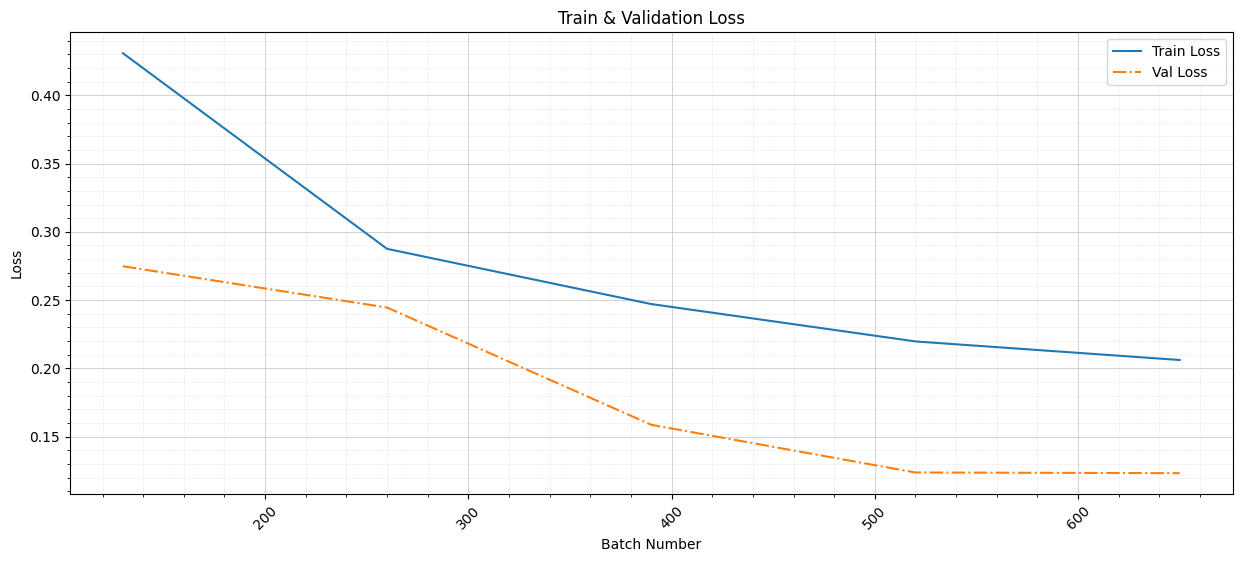

In [45]:
# -- Plot training and validation loss vs batch number ------------------------------------------------------
import matplotlib.pyplot as plt

def plot_train_val_loss(batches_seen, train_losses, val_losses):
    logger.info("Generating plot: training and validation loss vs batch number.")

    fig, ax1 = plt.subplots(figsize=(15,6))

    # Plot training and validation loss against epochs
    ax1.plot(batches_seen, train_losses, label="Train Loss")
    ax1.plot(batches_seen, val_losses, linestyle="-.", label="Val Loss")
    ax1.set_xlabel("Batch Number")
    #ax1.set_ylim(0)
    ax1.set_ylabel("Loss")
    ax1.set_title("Train & Validation Loss")
    ax1.legend(loc="upper right")
    # --- Add Subgrid (Minor Grid Lines) ---
    ax1.minorticks_on()  # Enable minor ticks
    # Major grid (main grid lines)
    ax1.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.8)
    # Minor grid (subgrid lines)
    ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
    ax1.grid(True)

    #fig.tight_layout()  # Adjust layout to make room
    plt.xticks(rotation=45)
    plt.savefig(f"loss-plot-finetune-classification-{run_id}.pdf")
    plt.show()

plot_train_val_loss(batches_seen, train_losses, val_losses)

In [46]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 92.31%
Validation accuracy: 93.29%
Test accuracy: 92.67%
